In [1]:
import os
import random
from PIL import Image
import torchvision.transforms as T
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import LayerGradCam
from torchvision import models, transforms,datasets

C:\Users\jonid\Documents\GitHub\JUN25-BDS-INT-BLOODCELLS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Define the preprocessing transformations
preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load('resnet_model_free_lastlayer.pth',
                    weights_only=False,
                    map_location=device)

if isinstance(model, torch.nn.DataParallel):
    model = model.module

In [5]:
from torchvision import models, transforms,datasets
from torch.utils.data import DataLoader

# Preprocessing for the model
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

# Load class names from training set
dataset_train = datasets.ImageFolder(root='../../../Spanish Dataset/train_test_val_data/train_oversampling', transform=transform)
class_names = dataset_train.classes

# Root path for each class
train_root = '../../../Spanish Dataset/train_test_val_data/train_oversampling'

print(class_names)


['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


C:\Users\jonid\AppData\Local\Temp\ipykernel_46192\2035594961.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])


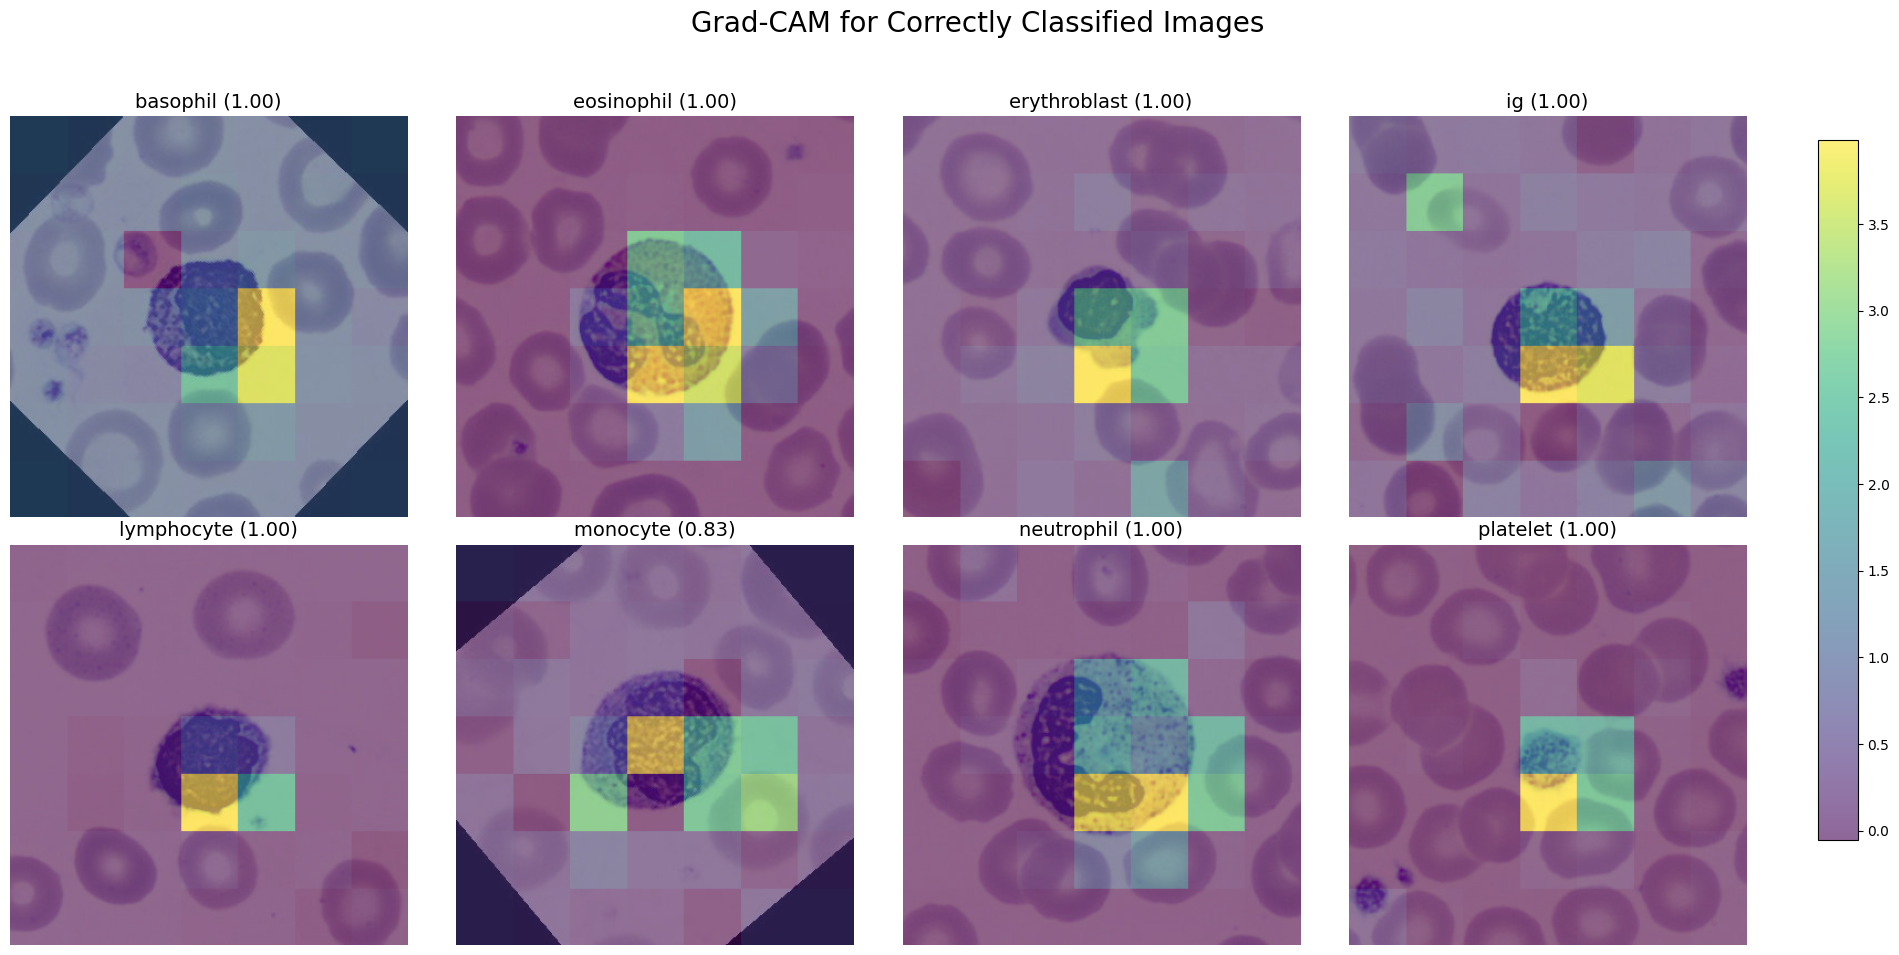

In [6]:
# Load the class names
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
dataset_train = datasets.ImageFolder(root='../../../Spanish Dataset/train_test_val_data/train_oversampling', transform=transform)
class_names = dataset_train.classes

# Create 2x4 subplot for correct predictions
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Grad-CAM for Correctly Classified Images', fontsize=20)

im = None  # will store the last imshow for colorbar

for i, class_name in enumerate(class_names):
    found = False
    while not found:
        # Random image from the class folder
        class_folder = os.path.join('../../../Spanish Dataset/train_test_val_data/train_oversampling', class_name)
        random_image_name = random.choice(os.listdir(class_folder))
        image_path = os.path.join(class_folder, random_image_name)

        img = Image.open(image_path).convert('RGB')
        original_img_size = img.size

        # Preprocess
        input_tensor = preprocess(img)
        input_batch = input_tensor.unsqueeze(0).to(device)

        # Prediction
        with torch.no_grad():
            output = model(input_batch)
            probs = torch.nn.functional.softmax(output[0], dim=0)
            predicted_idx = torch.argmax(probs).item()
            confidence = probs[predicted_idx].item()

        # Check if prediction matches the true class
        if class_names[predicted_idx] == class_name:
            found = True
            class_index = predicted_idx

            # Grad-CAM
            target_layer = model.layer4[-1]
            grad_cam = LayerGradCam(model, target_layer)
            attribution = grad_cam.attribute(input_batch, target=class_index)

            resized_attribution = F.interpolate(
                attribution,
                size=(original_img_size[1], original_img_size[0]),
                mode='nearest'
            )
            attribution_heatmap = resized_attribution.squeeze().detach().cpu().numpy()

            row, col = i // 4, i % 4
            ax[row, col].imshow(img)
            im = ax[row, col].imshow(attribution_heatmap, cmap='viridis', alpha=0.6)
            ax[row, col].set_title(f"{class_name} ({confidence:.2f})", fontsize=14)
            ax[row, col].axis('off')

# Add a single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax)

plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
plt.show()


C:\Users\jonid\AppData\Local\Temp\ipykernel_46192\276884538.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])


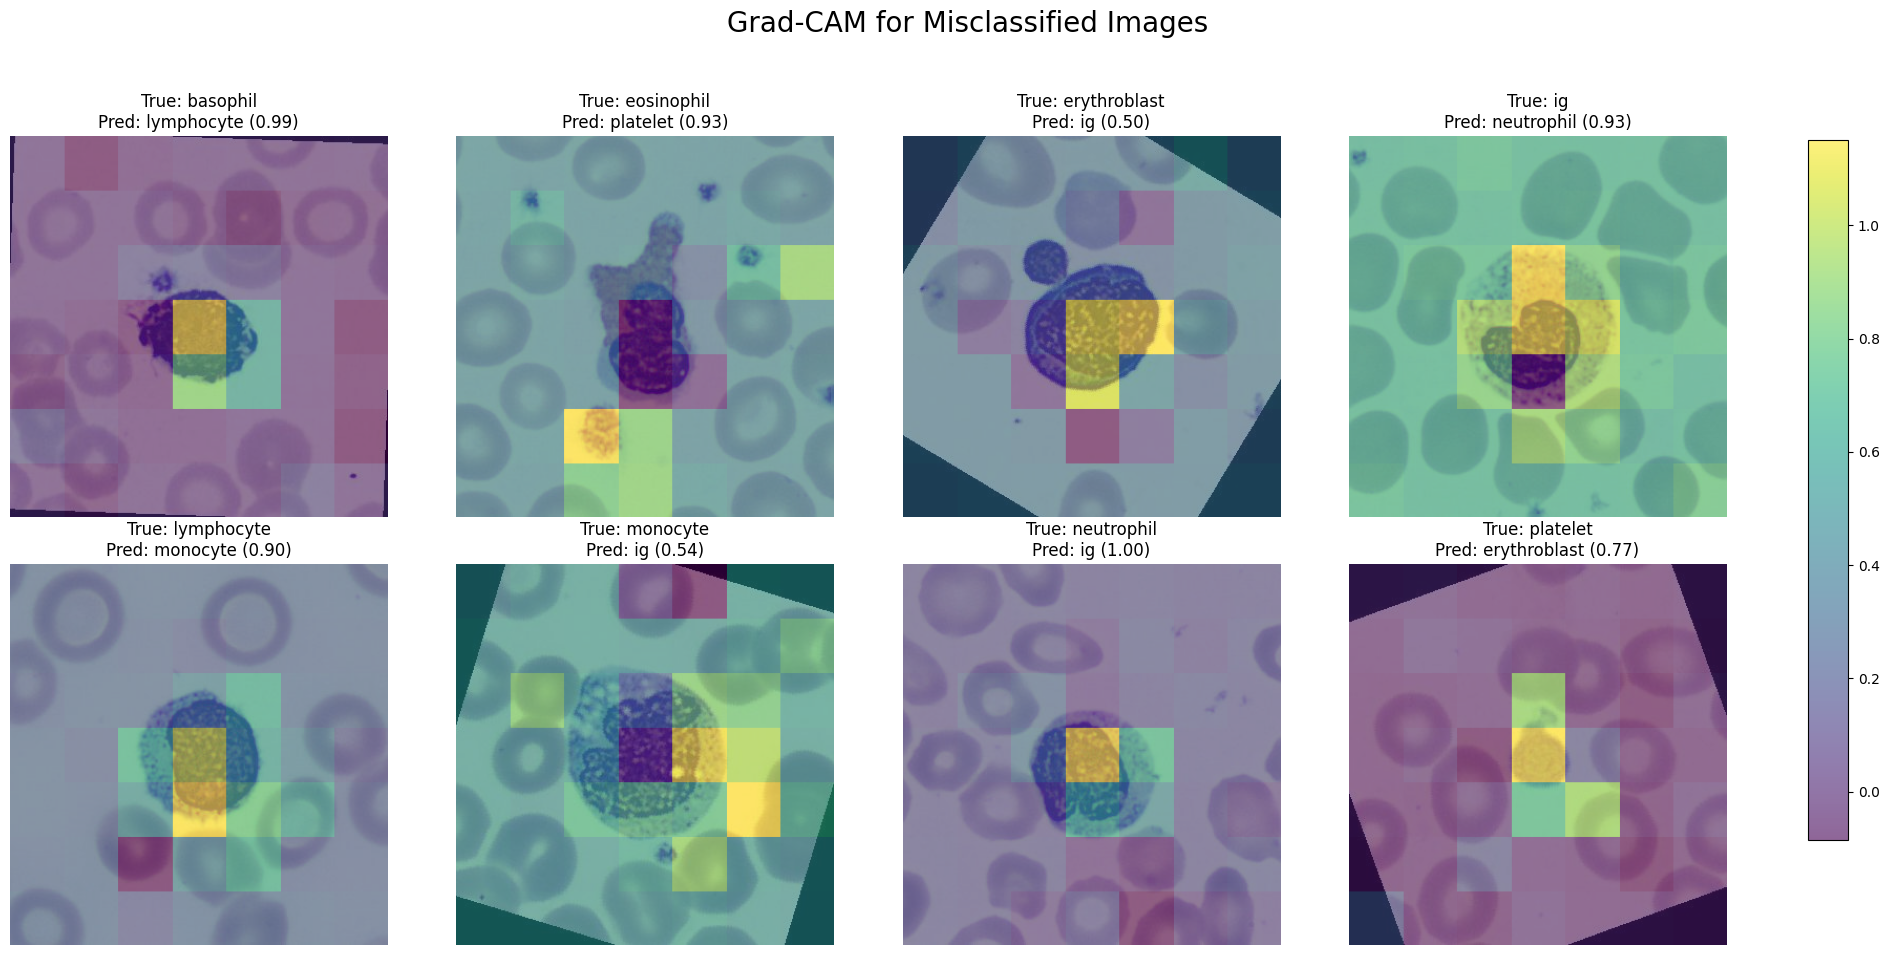

In [7]:
# Create 2x4 subplot for misclassified predictions
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Grad-CAM for Misclassified Images', fontsize=20)

im = None  # will store the last imshow for colorbar

for i, class_name in enumerate(class_names):
    found = False
    while not found:
        class_folder = os.path.join('../../../Spanish Dataset/train_test_val_data/train_oversampling', class_name)
        random_image_name = random.choice(os.listdir(class_folder))
        image_path = os.path.join(class_folder, random_image_name)

        img = Image.open(image_path).convert('RGB')
        original_img_size = img.size

        # Preprocess
        input_tensor = preprocess(img)
        input_batch = input_tensor.unsqueeze(0).to(device)

        # Prediction
        with torch.no_grad():
            output = model(input_batch)
            probs = torch.nn.functional.softmax(output[0], dim=0)
            predicted_idx = torch.argmax(probs).item()
            confidence = probs[predicted_idx].item()

        # Check if misclassified
        if class_names[predicted_idx] != class_name:
            found = True

            # Grad-CAM
            target_layer = model.layer4[-1]
            grad_cam = LayerGradCam(model, target_layer)
            attribution = grad_cam.attribute(input_batch, target=predicted_idx)

            resized_attribution = F.interpolate(
                attribution,
                size=(original_img_size[1], original_img_size[0]),
                mode='nearest'
            )
            attribution_heatmap = resized_attribution.squeeze().detach().cpu().numpy()

            row, col = i // 4, i % 4
            ax[row, col].imshow(img)
            im = ax[row, col].imshow(attribution_heatmap, cmap='viridis', alpha=0.6)
            ax[row, col].set_title(f"True: {class_name}\nPred: {class_names[predicted_idx]} ({confidence:.2f})", fontsize=12)
            ax[row, col].axis('off')

# Add a single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax)

plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
plt.show()


From this Grad-CAM visualization of misclassified images, we can make a few key interpretations about why the model is making mistakes:

1. The model often focuses on the wrong regions of the cell.
In several misclassifications (i.e. basophil, lymphocyte), the highest activation areas (bright yellow) are not centered on the most distinctive morphological features, especially the nucleus shape and granule patterns. Instead, it sometimes locks onto small peripheral areas, background artifacts, or red blood cells nearby, which can dilute its ability to differentiate the cell type.

2. Some wrong predictions show "partial" focus on the right area.
Example: erythroblast. The heatmap still partially highlights the nucleus but misses the full nuclear contour and instead attends to a patch of cytoplasm. This suggests the model knows where to look, but fails to capture the complete discriminative pattern, which could make borderline cases ambiguous.

3. Background context might be misleading the model.
In eosinophil and ig, strong activation sometimes appears outside the cell.
This implies the model might be overfitting to contextual cues of the image instead of purely morphological features.

4. Class confusions align with biologically similar cells.
Lymphocyte and Monocyte, or Ig and Neutrophil are common confusions even for pathologist experts because of overlapping morphological features.


Conclusion:
The Grad-CAM plots show that wrong predictions often come from:

- Attention misplacement (focusing on background or irrelevant parts of the cell)
- Incomplete feature capture (only part of the nucleus or cytoplasm)
- Visual similarity between classes

This reinforces the idea that errors aren’t purely random they stem from genuine visual similarity in the data.